In [116]:
pip install tensorflow-gpu

  Using cached tensorflow-gpu-2.12.0.tar.gz (2.6 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [117]:
# importing important libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [118]:
# 1. Load dataset

df = pd.read_csv('/content/flight_data_2024_sample.csv')

In [119]:
df.head()

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,4,18,4,2024-04-18,MQ,3535.0,DFW,"Dallas/Fort Worth, TX",Texas,...,0,151.0,144.0,119.0,835.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,AA,148.0,CLT,"Charlotte, NC",North Carolina,...,0,286.0,273.0,253.0,1773.0,0,0,0,0,0
2,2024,12,12,4,2024-12-12,9E,5440.0,CHA,"Chattanooga, TN",Tennessee,...,0,59.0,50.0,29.0,106.0,0,0,0,0,0
3,2024,4,8,1,2024-04-08,WN,1971.0,OMA,"Omaha, NE",Nebraska,...,0,180.0,177.0,163.0,1099.0,0,0,0,0,0
4,2024,2,16,5,2024-02-16,WN,862.0,BWI,"Baltimore, MD",Maryland,...,0,90.0,96.0,76.0,399.0,0,0,0,0,0


In [120]:
df.dtypes

,0
year,int64
month,int64
day_of_month,int64
day_of_week,int64
fl_date,object
op_unique_carrier,object
op_carrier_fl_num,float64
origin,object
origin_city_name,object
origin_state_nm,object


In [121]:
df.shape

(10000, 35)

In [122]:
# Data Cleaning

# Drop duplicates and irrelevant column
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

After removing duplicates: (10000, 35)


In [123]:
# Remove cancelled and diverted flights
df = df[(df['cancelled'] == 0) & (df['diverted'] == 0)]

In [124]:
# Fill missing delay columns with 0
delay_cols = ['carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']
df[delay_cols] = df[delay_cols].fillna(0)


In [125]:
# Drop irrelevant/leaky columns
drop_cols = ['fl_date', 'dep_time', 'arr_time', 'actual_elapsed_time',
             'cancellation_code', 'wheels_off', 'wheels_on']
df = df.drop(columns=drop_cols)

In [126]:
df.columns

Index(['year', 'month', 'day_of_month', 'day_of_week', 'op_unique_carrier',
       'op_carrier_fl_num', 'origin', 'origin_city_name', 'origin_state_nm',
       'dest', 'dest_city_name', 'dest_state_nm', 'crs_dep_time', 'dep_delay',
       'taxi_out', 'taxi_in', 'crs_arr_time', 'arr_delay', 'cancelled',
       'diverted', 'crs_elapsed_time', 'air_time', 'distance', 'carrier_delay',
       'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay'],
      dtype='object')

In [127]:
# Handle Extreme Delays

# Clip arrival delays to 0-300 minutes
df['arr_delay'] = df['arr_delay'].clip(0, 300)

# Optional: log-transform positive delays for stabilization
df['arr_delay_log'] = np.log1p(df['arr_delay'] - df['arr_delay'].min() + 1)

In [128]:
# Feature Engineering

# Convert scheduled departure and arrival times to minutes
def convert_hhmm_to_minutes(hhmm):
    hhmm = int(hhmm)
    return (hhmm // 100) * 60 + (hhmm % 100)

df['crs_dep_time'] = df['crs_dep_time'].apply(convert_hhmm_to_minutes)
df['crs_arr_time'] = df['crs_arr_time'].apply(convert_hhmm_to_minutes)

# Create derived features
df['dep_hour'] = df['crs_dep_time'] // 60
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 6 else 0)


In [129]:
# Encode Categorical Variables
categorical_cols = ['op_unique_carrier', 'origin', 'dest']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Drop remaining text columns
text_cols = ['origin_city_name', 'dest_city_name', 'origin_state_nm', 'dest_state_nm']
df = df.drop(columns=text_cols)

In [130]:
df.dtypes

,0
year,int64
month,int64
day_of_month,int64
day_of_week,int64
op_carrier_fl_num,float64
...,...
dest_WYS,bool
dest_XNA,bool
dest_XWA,bool
dest_YAK,bool


In [131]:
# Define Features and Target

features = ['year', 'month', 'day_of_month', 'day_of_week', 'dep_delay',
            'taxi_out', 'taxi_in', 'crs_dep_time', 'crs_arr_time', 'crs_elapsed_time',
            'air_time', 'distance', 'carrier_delay', 'weather_delay', 'nas_delay',
            'security_delay', 'late_aircraft_delay', 'dep_hour', 'is_weekend']

# Include one-hot encoded categorical columns
encoded_cols = [col for col in df.columns if col.startswith(('op_unique_carrier_', 'origin_', 'dest_'))]
features.extend(encoded_cols)

X = df[features]
y = df['arr_delay']

In [132]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [133]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler

num_cols = ['year', 'month', 'day_of_month', 'day_of_week', 'dep_delay',
            'taxi_out', 'taxi_in', 'crs_dep_time', 'crs_arr_time', 'crs_elapsed_time',
            'air_time', 'distance', 'carrier_delay', 'weather_delay', 'nas_delay',
            'security_delay', 'late_aircraft_delay', 'dep_hour']

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [135]:
#Initializing ANN

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import Huber

# Model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

# compile

model.compile(optimizer=Adam(0.001), loss=Huber(delta=1.0), metrics=['mae'])

In [136]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 11.7366 - mae: 12.1087 - val_loss: 3.1270 - val_mae: 3.3614
Epoch 2/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.2747 - mae: 2.5348 - val_loss: 2.8623 - val_mae: 3.1174
Epoch 3/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.5835 - mae: 2.8391 - val_loss: 2.6659 - val_mae: 2.9131
Epoch 4/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.5073 - mae: 2.7631 - val_loss: 3.0279 - val_mae: 3.2458
Epoch 5/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.1268 - mae: 2.3765 - val_loss: 2.5886 - val_mae: 2.8237
Epoch 6/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.1370 - mae: 2.3715 - val_loss: 2.8295 - val_mae: 3.1169
Epoch 7/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.8718 - mae: 2.1151 - val_loss: 2.7094 - val_mae: 2.9515
Epoch 8/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.9271 - mae: 2.1621 - val_loss: 2.8012 - val_mae: 3.0380
Epoch 9/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - 

In [137]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f} minutes")
print(f"RMSE: {rmse:.2f} minutes")
print(f"R² Score: {r2:.4f}")


62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE: 1.83 minutes
RMSE: 7.63 minutes
R² Score: 0.9662


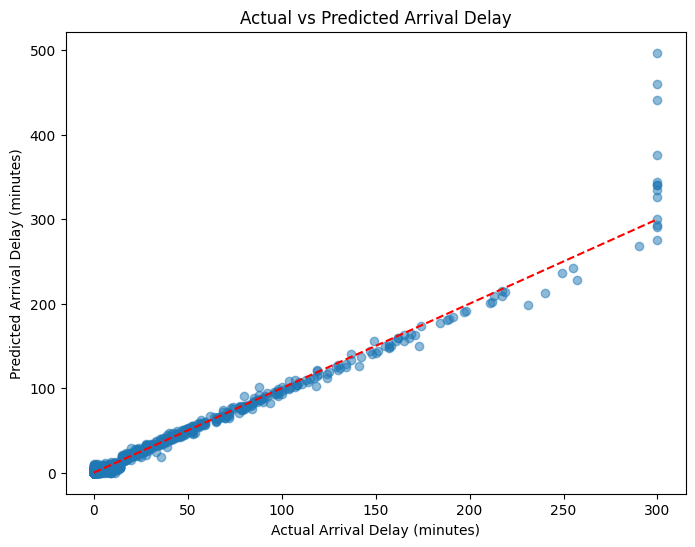

In [138]:
# 1. Actual vs Predicted Arrival Delays
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([0, 300], [0, 300], 'r--')  # Perfect prediction line
plt.xlabel("Actual Arrival Delay (minutes)")
plt.ylabel("Predicted Arrival Delay (minutes)")
plt.title("Actual vs Predicted Arrival Delay")
plt.show()


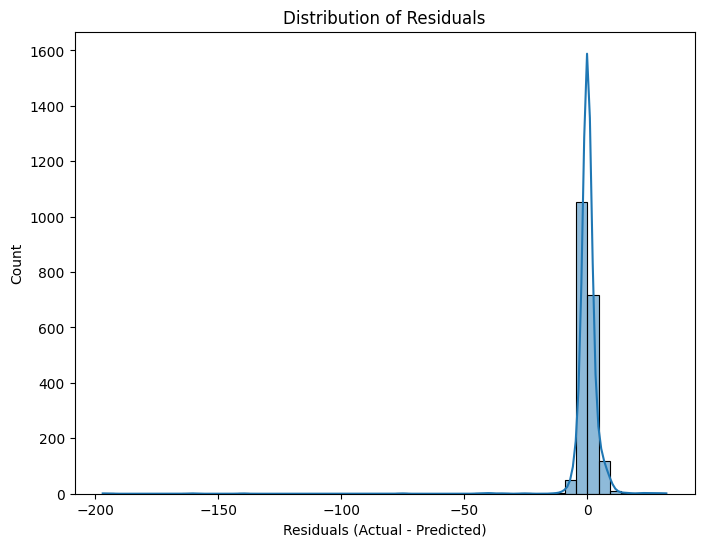

In [139]:
# 2. Residuals Plot
residuals = y_test - y_pred.flatten()
plt.figure(figsize=(8,6))
sns.histplot(residuals, bins=50, kde=True)
plt.xlabel("Residuals (Actual - Predicted)")
plt.title("Distribution of Residuals")
plt.show()

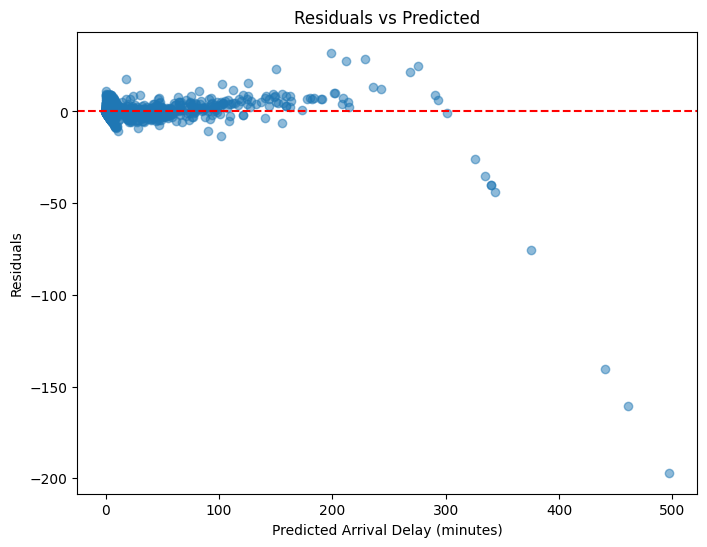

In [140]:
# 3. Residuals vs Predicted
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted Arrival Delay (minutes)")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()


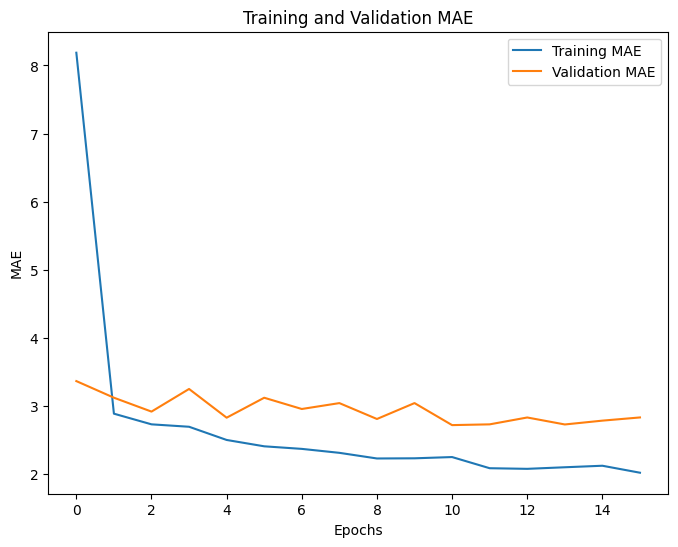

In [141]:
# 4. Training and Validation Loss Curve
plt.figure(figsize=(8,6))
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.title("Training and Validation MAE")
plt.legend()
plt.show()